# Embedding Birth-Death Processes within a Dynamic Stochastic Block Model (BD-SBM)

This notebook demonstrates how to:

1) Generate or load data (interaction_counts, alive_matrix, birth/death times),

2) Fit the dynamic BD-SBM using Variational EM (VEM) (dense or sparse interactions),

3) Inspect outputs (ELBO, parameter estimates, posterior community memberships, and accuracy).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Optional: silence occasional SciPy fsolve warnings in this notebook output.
import warnings
warnings.filterwarnings(
    "ignore",
    message="The iteration is not making good progress.*",
    category=RuntimeWarning,
)

# 1) Generate or load data

## A) Load data 
Provide:
- **interaction_counts**: array-like of shape *(N, N)* or a `scipy.sparse.spmatrix` of shape *(N, N)*  
  Pairwise interaction counts over the full study interval (symmetric, with a zero diagonal).

- **alive_matrix**: array-like of shape *(N, N)*  
  Pairwise co-aliveness (exposure) matrix: the number of observation times at which individuals *i* and *j* are simultaneously alive/active.

- **df_births_deaths**: `pandas.DataFrame` with at least the columns `['id', 't_birth', 't_death']`  
  Per-individual birth and death times. The `id` values must be consistent with the row/column order of the matrices.


## B) Generate synthetic data
We generate birth/death times and then the aggregated interaction matrices.

### Import the data generation model 

In [2]:
from BDSBM.data_generation import data_generation

### Parameter settings for data generation

In [3]:
lamb = np.array([0.05, 0.04, 0.03, 0.02])   # birth rate per community
mu = np.array([0.025, 0.02, 0.01, 0.05])     # death rate per community
#mu = np.array([0, 0, 0, 0])                # for a pure-birth process (set mu = 0)
t_end = 100                                 # final time (end of the simulation horizon)
L_0 = [[10, 11, 7, 12]]                     # initial number of individuals per community
N_0 = np.sum(L_0)                           # initial number of individuals
K = len(L_0[0])                             # number of communities 
pi_true = np.array([
    [0.75, 0.36, 0.2, 0.16],
    [0.36, 0.91, 0.22, 0.24],
    [0.2, 0.22, 0.82, 0.28],
    [0.16, 0.24, 0.28, 0.66]], dtype=float) # SBM connection probability matrix
snapshots_times = np.arange(0, t_end + 1, 1)# snapshot times at which graphs are generated.

### Run the data-generation step

In [4]:
data = data_generation(lamb, 
                       mu, 
                       t_end, 
                       L_0, 
                       K, 
                       pi_true, 
                       snapshots_times)

In [5]:
interaction_counts, alive_matrix, df_births_deaths = data 

# 2) Fit the dynamic BD-SBM using Variational EM (VEM) (dense or sparse interactions)


You can either **load** the required inputs or **generate** synthetic data using the data-generation utilities.

### Inputs

- **interaction_counts**: array-like of shape *(N, N)* or a `scipy.sparse.spmatrix` of shape *(N, N)*  
  Pairwise interaction counts over the full study interval (symmetric, with a zero diagonal).

- **alive_matrix**: array-like of shape *(N, N)*  
  Pairwise co-aliveness (exposure) matrix: the number of observation times at which individuals *i* and *j* are simultaneously alive/active.

- **df_births_deaths**: `pandas.DataFrame` with at least the columns `['id', 't_birth', 't_death']`  
  Per-individual birth and death times. The `id` values must be consistent with the row/column order of the matrices.

### Initialization

- **delta_init**: array-like of shape *(N, K)* or *(N₀, K)*  
  Initial community-membership probabilities (variational responsibilities).  
  If only *(N₀, K)* is provided, it is interpreted as the initialization for individuals alive at time *t = 0*.

### Outputs

The `fit()` method returns:

`(pi_est, beta_est, lambda_est, mu_est, delta_est, gamma_est, gamma_mar_est, elbo_values, icl, icl_soft_values)`

- **pi_est**: array-like, shape *(K, K)*  
  Estimated SBM connection probability matrix.

- **beta_est**: array-like, shape *(K,)*  
  Estimated community proportions at time *t = 0*.

- **lambda_est**: float  
  Estimated birth rate.

- **mu_est**: float  
  Estimated death rate.

- **delta**: array-like, shape *(N, K)*  
  Estimated community-membership probabilities for all individuals.

- **gamma**: array-like, shape *(T, K, N+1)*  
  Estimated transition probabilities for community sizes along the event timeline.  
  For event index *l*, community *k*, and count *n*, `gamma[l, k, n]` denotes the transition probability to move from *n* to *n* individuals in community *k* at event index *$\ell + 1 $* (time *$\tau_{\ell+1}$*).

- **gamma_mar**: array-like, shape *(T, K, N+1)*  
  Estimated marginal distributions of community sizes over the event timeline.  
  `gamma_mar[l, k, n]` is the probability that, at event index *$\ell$* (time *$\tau_{\ell}$*), there are *n* alive individuals in community *k*.

- **elbo_values**: list or array-like  
  Evidence Lower Bound (ELBO) values across VEM iterations (used to monitor convergence).

- **icl**: float  
  Integrated Completed Likelihood (ICL) criterion.

- **icl_soft_values**: list or array-like  
  Soft/variational version of the ICL criterion across iterations.


### Initialize the variational distribution (delta) for a fixed K

In [6]:
method = 'random' #or 'kmeans'

K_init = 4
N = len(df_births_deaths)
seed = 3

In [7]:
# --- Initialization of delta ---

# Initialization using K-means
if method == 'kmeans':  
    from sklearn.cluster import KMeans
    kmeans_weight = 0.3
    A = (2*interaction_counts-alive_matrix)/alive_matrix
    A[np.isnan(A)] = 0
    kmeans = KMeans(n_clusters=K_init, random_state=seed).fit(A)
    z = kmeans.labels_ 
    Z = np.eye(K)[z].T
    delta_init = kmeans_weight * Z.transpose() + (1 - kmeans_weight)/K

# Random initialization
elif method == 'random':
    rng = np.random.default_rng(seed)
    delta_init = rng.random((N, K_init)) + 1e-3
    delta_init /= delta_init.sum(axis=1, keepdims=True)

### Import the Dynamic BD-SBM VEM model for dense or sparse data

In [8]:
from BDSBM_Specific_birth_death_rates.Dynamic_BDSBM_VEM import DynamicBDSBM_VEM
#from BDSBM_Specific_birth_death_rates.Dynamic_BDSBM_VEM_sparse import DynamicBDSBM_VEM_sparse

### Run the BD-SBM VEM model

In [9]:
# Run the model using either a dense or a sparse interaction-count matrix

model_type = 'dense'  # options: 'dense' or 'sparse'

if model_type == 'dense':
    model = DynamicBDSBM_VEM(
        interaction_counts,
        alive_matrix,
        df_births_deaths,
        delta_init,
        max_iters=50,
        tol=1e-10,
    )
    sol = model.fit()

elif model_type == 'sparse':
    model = DynamicBDSBM_VEM_sparse(
        interaction_counts_sparse,
        alive_matrix,
        df_births_deaths,
        delta_init,
        max_iters=50,
        tol=1e-10,
    )
    sol = model.fit()

else:
    raise ValueError("model_type must be either 'dense' or 'sparse'")

pi_est, beta_est, lambda_est, mu_est, delta_est, gamma_est, gamma_mar_est, elbo, icl, icl_soft = sol


Iteration 1, ELBO: -414341.91143057076


/home/gabriela/Documents/PhD/paper_2_simulations/BDSBM_Specific_birth_death_rates/utils.py:143: RuntimeWarning: divide by zero encountered in log
  term5 = delta[V_t0]*(np.log(delta[V_t0] ))
/home/gabriela/Documents/PhD/paper_2_simulations/BDSBM_Specific_birth_death_rates/utils.py:143: RuntimeWarning: invalid value encountered in multiply
  term5 = delta[V_t0]*(np.log(delta[V_t0] ))



Iteration 2, ELBO: -404193.88730146113

Iteration 3, ELBO: -391978.32107796875

Iteration 4, ELBO: -372317.9934146116

Iteration 5, ELBO: -318100.98761853355

Iteration 6, ELBO: -211926.69286558774

Iteration 7, ELBO: -327330.4705447844

Iteration 8, ELBO: -318056.25176583347

Iteration 9, ELBO: -318052.66997890215

Iteration 10, ELBO: -318052.6718440602

Iteration 11, ELBO: -318052.67185005767

Iteration 12, ELBO: -318052.67185009096

Iteration 13, ELBO: -318052.6718500906

Iteration 14, ELBO: -318052.6718500908

Iteration 15, ELBO: -318052.67185009085
Convergence reached


## Model selection: choose K via ICL

### Define a grid of candidate K values and random seeds

In [10]:
Ks = range(1, 6)
seeds = range(1,51)

### Run the model across multiple random seeds and candidate values of K

In [11]:
kmeans_weight = 0.3   # weight for the k-means-based initialization

sol_BDSBM = {}
K_eff = {}
delta_initial = {}

#multiple initializations to avoid local optima
for K in Ks: 
    
    for seed in seeds:
        rng = np.random.default_rng(seed)
    
        
        print(f"K={K}, seed={seed}")

        # --- Initialization of delta ---
        if method == 'kmeans':
            kmeans = KMeans(n_clusters=K, random_state=seed).fit(A)
            z = kmeans.labels_ 
            Z = np.eye(K)[z].T
            delta_init = kmeans_weight * Z.transpose() + (1 - kmeans_weight)/K

        elif method == 'random':
            
            delta_init = rng.random((N, K)) + 1e-3
            delta_init /= delta_init.sum(axis=1, keepdims=True)

        delta_initial[K, seed] = delta_init
        
        # --- Fit the model ---    
        model_0 = DynamicBDSBM_VEM(interaction_counts, 
                                   alive_matrix, 
                                   df_births_deaths, 
                                   delta_init, 
                                   max_iters=50, 
                                   tol=1e-10)
        sol_BDSBM[K, seed] = model_0.fit()
        
        pi_est, beta, lambda_est, mu_est, delta, gamma_est, gamma_mar_est, elbo, icl, icl_soft = sol_BDSBM[K, seed]
        
        # --- Compute the effective number of non-empty clusters (MAP assignment) ---       
        idx = np.argmax(delta, axis=1)
        K_effective = np.unique(idx).size
        K_eff[(K, seed)] = K_effective
        

K=1, seed=1

Iteration 1, ELBO: -429816.0953617041

Iteration 2, ELBO: -429816.0953617041
Convergence reached
K=1, seed=2

Iteration 1, ELBO: -429816.0953617041

Iteration 2, ELBO: -429816.0953617041
Convergence reached
K=1, seed=3

Iteration 1, ELBO: -429816.0953617041

Iteration 2, ELBO: -429816.0953617041
Convergence reached
K=1, seed=4

Iteration 1, ELBO: -429816.0953617041

Iteration 2, ELBO: -429816.0953617041
Convergence reached
K=1, seed=5

Iteration 1, ELBO: -429816.0953617041

Iteration 2, ELBO: -429816.0953617041
Convergence reached
K=1, seed=6

Iteration 1, ELBO: -429816.0953617041

Iteration 2, ELBO: -429816.0953617041
Convergence reached
K=1, seed=7

Iteration 1, ELBO: -429816.0953617041

Iteration 2, ELBO: -429816.0953617041
Convergence reached
K=1, seed=8

Iteration 1, ELBO: -429816.0953617041

Iteration 2, ELBO: -429816.0953617041
Convergence reached
K=1, seed=9

Iteration 1, ELBO: -429816.0953617041

Iteration 2, ELBO: -429816.0953617041
Convergence reached
K=1, seed=


Iteration 17, ELBO: -406442.0426481318

Iteration 18, ELBO: -406442.0270808927

Iteration 19, ELBO: -406442.0123604683

Iteration 20, ELBO: -406441.99836670724

Iteration 21, ELBO: -406441.9850024921

Iteration 22, ELBO: -406441.97218020074

Iteration 23, ELBO: -406441.9598237846

Iteration 24, ELBO: -406441.9478652101

Iteration 25, ELBO: -406441.936243567

Iteration 26, ELBO: -406441.92490360996

Iteration 27, ELBO: -406441.9137947569

Iteration 28, ELBO: -406441.90287018445

Iteration 29, ELBO: -406441.8920860485

Iteration 30, ELBO: -406441.8814008319

Iteration 31, ELBO: -406441.87077474414

Iteration 32, ELBO: -406441.86016917886

Iteration 33, ELBO: -406441.84954624926

Iteration 34, ELBO: -406441.83886833774

Iteration 35, ELBO: -406441.82809768396

Iteration 36, ELBO: -406441.8171960074

Iteration 37, ELBO: -406441.8061241563

Iteration 38, ELBO: -406441.7948418028

Iteration 39, ELBO: -406441.7833071785

Iteration 40, ELBO: -406441.7714769048

Iteration 41, ELBO: -406441.759


Iteration 21, ELBO: -406441.68450919905

Iteration 22, ELBO: -406441.6690332656

Iteration 23, ELBO: -406441.6529390086

Iteration 24, ELBO: -406441.6362575827

Iteration 25, ELBO: -406441.61908148514

Iteration 26, ELBO: -406441.6016000682

Iteration 27, ELBO: -406441.5841592595

Iteration 28, ELBO: -406441.56735307013

Iteration 29, ELBO: -406441.55216655973

Iteration 30, ELBO: -406441.54019253055

Iteration 31, ELBO: -406441.5339492596

Iteration 32, ELBO: -406441.5373138175

Iteration 33, ELBO: -406441.5560331696

Iteration 34, ELBO: -406441.59813211666

Iteration 35, ELBO: -406441.67375805357

Iteration 36, ELBO: -406441.7936565304

Iteration 37, ELBO: -406441.96544541576

Iteration 38, ELBO: -406442.18781312095

Iteration 39, ELBO: -406442.4450706574

Iteration 40, ELBO: -406442.7074212444

Iteration 41, ELBO: -406442.9414992042

Iteration 42, ELBO: -406443.12554451363

Iteration 43, ELBO: -406443.255835325

Iteration 44, ELBO: -406443.34121038776

Iteration 45, ELBO: -406443.3


Iteration 24, ELBO: -406441.9394263898

Iteration 25, ELBO: -406441.9280137878

Iteration 26, ELBO: -406441.91684586665

Iteration 27, ELBO: -406441.90587484156

Iteration 28, ELBO: -406441.89505611703

Iteration 29, ELBO: -406441.88434759545

Iteration 30, ELBO: -406441.87370905775

Iteration 31, ELBO: -406441.8631016318

Iteration 32, ELBO: -406441.8524872687

Iteration 33, ELBO: -406441.8418283242

Iteration 34, ELBO: -406441.8310871101

Iteration 35, ELBO: -406441.8202255345

Iteration 36, ELBO: -406441.80920471373

Iteration 37, ELBO: -406441.7979846743

Iteration 38, ELBO: -406441.78652406944

Iteration 39, ELBO: -406441.77477997384

Iteration 40, ELBO: -406441.76270780445

Iteration 41, ELBO: -406441.75026138435

Iteration 42, ELBO: -406441.73739330564

Iteration 43, ELBO: -406441.72405568586

Iteration 44, ELBO: -406441.7102016116

Iteration 45, ELBO: -406441.6957876003

Iteration 46, ELBO: -406441.6807776571

Iteration 47, ELBO: -406441.66514988255

Iteration 48, ELBO: -40644


Iteration 27, ELBO: -406441.57422335196

Iteration 28, ELBO: -406441.558209574

Iteration 29, ELBO: -406441.5446532475

Iteration 30, ELBO: -406441.5356411918

Iteration 31, ELBO: -406441.53442493477

Iteration 32, ELBO: -406441.54591048515

Iteration 33, ELBO: -406441.5771458064

Iteration 34, ELBO: -406441.63747929543

Iteration 35, ELBO: -406441.7377199159

Iteration 36, ELBO: -406441.8873977101

Iteration 37, ELBO: -406442.0896933792

Iteration 38, ELBO: -406442.33535077126

Iteration 39, ELBO: -406442.59978539805

Iteration 40, ELBO: -406442.84924650635

Iteration 41, ELBO: -406443.0555956041

Iteration 42, ELBO: -406443.20770996105

Iteration 43, ELBO: -406443.3103011556

Iteration 44, ELBO: -406443.3753434695

Iteration 45, ELBO: -406443.41496979666

Iteration 46, ELBO: -406443.4385295677

Iteration 47, ELBO: -406443.4523351046

Iteration 48, ELBO: -406443.46035645425

Iteration 49, ELBO: -406443.46499416034

Iteration 50, ELBO: -406443.4676679383
K=2, seed=15

Iteration 1, ELB

...


Iteration 7, ELBO: -317911.86339125945

Iteration 8, ELBO: -317905.4191121445

Iteration 9, ELBO: -317904.6865314136

Iteration 10, ELBO: -317905.8110147227

Iteration 11, ELBO: -317907.16762644745

Iteration 12, ELBO: -317908.5311901569

Iteration 13, ELBO: -317909.8559053909

Iteration 14, ELBO: -317911.1255147396

Iteration 15, ELBO: -317912.3380726882

Iteration 16, ELBO: -317913.50044146157

Iteration 17, ELBO: -317914.62365186895

Iteration 18, ELBO: -317915.71938244195

Iteration 19, ELBO: -317916.79789940035

Iteration 20, ELBO: -317917.8672265399

Iteration 21, ELBO: -317918.9330867025

Iteration 22, ELBO: -317919.99921452004

Iteration 23, ELBO: -317921.06778456393

Iteration 24, ELBO: -317922.1398234693

Iteration 25, ELBO: -317923.21555381245

Iteration 26, ELBO: -317924.29465929314

Iteration 27, ELBO: -317925.3764791344

Iteration 28, ELBO: -317926.4601455655

Iteration 29, ELBO: -317927.54467839294

Iteration 30, ELBO: -317928.62904852506

Iteration 31, ELBO: -317929.71


Iteration 10, ELBO: -317982.9743064253

Iteration 11, ELBO: -317983.3888817699

Iteration 12, ELBO: -317983.7880933697

Iteration 13, ELBO: -317984.1786870771

Iteration 14, ELBO: -317984.56294997816

Iteration 15, ELBO: -317984.94162346015

Iteration 16, ELBO: -317985.31498561945

Iteration 17, ELBO: -317985.6831834105

Iteration 18, ELBO: -317986.04632694233

Iteration 19, ELBO: -317986.404515128

Iteration 20, ELBO: -317986.7578424842

Iteration 21, ELBO: -317987.10640092276

Iteration 22, ELBO: -317987.4502802265

Iteration 23, ELBO: -317987.78956820065

Iteration 24, ELBO: -317988.12435074017

Iteration 25, ELBO: -317988.4547118699

Iteration 26, ELBO: -317988.7807337879

Iteration 27, ELBO: -317989.10249689966

Iteration 28, ELBO: -317989.4200798573

Iteration 29, ELBO: -317989.73355959466

Iteration 30, ELBO: -317990.04301136604

Iteration 31, ELBO: -317990.34850878076

Iteration 32, ELBO: -317990.6501238408

Iteration 33, ELBO: -317990.94792697235

Iteration 34, ELBO: -317991.


Iteration 13, ELBO: -318035.1933999553

Iteration 14, ELBO: -318036.21301730257

Iteration 15, ELBO: -318037.38170180714

Iteration 16, ELBO: -318038.6773514174

Iteration 17, ELBO: -318040.0626396906

Iteration 18, ELBO: -318041.48923624866

Iteration 19, ELBO: -318042.9055651273

Iteration 20, ELBO: -318044.2652802996

Iteration 21, ELBO: -318045.5332321078

Iteration 22, ELBO: -318046.687440832

Iteration 23, ELBO: -318047.71772169066

Iteration 24, ELBO: -318048.6224859423

Iteration 25, ELBO: -318049.4052116492

Iteration 26, ELBO: -318050.0685488938

Iteration 27, ELBO: -318050.6156795006

Iteration 28, ELBO: -318051.0713948857

Iteration 29, ELBO: -318051.4413664408

Iteration 30, ELBO: -318051.73605951783

Iteration 31, ELBO: -318051.96719308186

Iteration 32, ELBO: -318052.14580886555

Iteration 33, ELBO: -318052.2818615145

Iteration 34, ELBO: -318052.38434335776

Iteration 35, ELBO: -318052.460868312

Iteration 36, ELBO: -318052.5176196763

Iteration 37, ELBO: -318052.55947


Iteration 16, ELBO: -318052.65578736324

Iteration 17, ELBO: -318052.6557581024

Iteration 18, ELBO: -318052.65572878905

Iteration 19, ELBO: -318052.65569942276

Iteration 20, ELBO: -318052.6556700031

Iteration 21, ELBO: -318052.65564053104

Iteration 22, ELBO: -318052.6556110052

Iteration 23, ELBO: -318052.65558142593

Iteration 24, ELBO: -318052.6555517933

Iteration 25, ELBO: -318052.6555221075

Iteration 26, ELBO: -318052.6554923679

Iteration 27, ELBO: -318052.6554625742

Iteration 28, ELBO: -318052.65543272725

Iteration 29, ELBO: -318052.6554028264

Iteration 30, ELBO: -318052.6553728716

Iteration 31, ELBO: -318052.6553428626

Iteration 32, ELBO: -318052.6553127994

Iteration 33, ELBO: -318052.6552826817

Iteration 34, ELBO: -318052.6552525104

Iteration 35, ELBO: -318052.65522228397

Iteration 36, ELBO: -318052.6551920034

Iteration 37, ELBO: -318052.6551616676

Iteration 38, ELBO: -318052.65513127705

Iteration 39, ELBO: -318052.65510083153

Iteration 40, ELBO: -318052.65


Iteration 19, ELBO: -317913.91683123907

Iteration 20, ELBO: -317915.0554084407

Iteration 21, ELBO: -317916.1628535559

Iteration 22, ELBO: -317917.2504721025

Iteration 23, ELBO: -317918.3270235151

Iteration 24, ELBO: -317919.3987235491

Iteration 25, ELBO: -317920.4696230105

Iteration 26, ELBO: -317921.54209319636

Iteration 27, ELBO: -317922.6172815719

Iteration 28, ELBO: -317923.6954859407

Iteration 29, ELBO: -317924.7764393576

Iteration 30, ELBO: -317925.85951669246

Iteration 31, ELBO: -317926.9438792223

Iteration 32, ELBO: -317928.0285731038

Iteration 33, ELBO: -317929.1125948771

Iteration 34, ELBO: -317930.19493411464

Iteration 35, ELBO: -317931.27460057667

Iteration 36, ELBO: -317932.3506410549

Iteration 37, ELBO: -317933.4221494603

Iteration 38, ELBO: -317934.48827252776

Iteration 39, ELBO: -317935.5482126972

Iteration 40, ELBO: -317936.6012291762

Iteration 41, ELBO: -317937.6466378259

Iteration 42, ELBO: -317938.68381028145

Iteration 43, ELBO: -317939.7121

### Selection frequency of the effective number of communities (K_eff)

In [12]:
Ks_sorted = sorted(Ks)
best_counts = {K: 0 for K in Ks_sorted}
best_counts_var = {K: 0 for K in Ks_sorted}

for seed in seeds:
    # Best K according to (hard) ICL for this seed
    best_K = max(Ks_sorted, key=lambda K: sol_BDSBM[(K, seed)][8])

    # Best K according to var-ICL for this seed
    best_K_var = max(Ks_sorted, key=lambda K: sol_BDSBM[(K, seed)][9][-1])

    # Count using the effective number of non-empty clusters
    best_counts[K_eff[(best_K, seed)]] += 1
    best_counts_var[K_eff[(best_K_var, seed)]] += 1

print("Number of times ICL selected each effective K:")
for K in Ks_sorted:
    print(f"K = {K}: {best_counts[K]} times")

print("Number of times var-ICL selected each effective K:")
for K in Ks_sorted:
    print(f"K = {K}: {best_counts_var[K]} times")

Number of times ICL selected each effective K:
K = 1: 0 times
K = 2: 0 times
K = 3: 1 times
K = 4: 49 times
K = 5: 0 times
Number of times var-ICL selected each effective K:
K = 1: 0 times
K = 2: 0 times
K = 3: 1 times
K = 4: 49 times
K = 5: 0 times


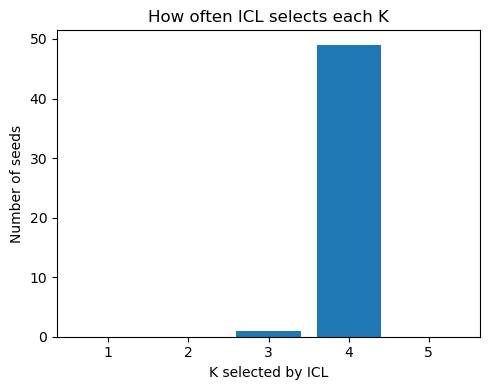

In [13]:
plt.figure(figsize=(5, 4))
plt.bar(list(best_counts.keys()), list(best_counts.values()))
plt.xlabel("K selected by ICL")
plt.ylabel("Number of seeds")
plt.title("How often ICL selects each K")
plt.savefig('figures/presentation_these/ICL_pi_high.png')
plt.xticks(Ks_sorted)
plt.tight_layout()
plt.show()

In [14]:
best_k_eff = max(best_counts, key=best_counts.get)
print("Best k_eff (most frequent):", best_k_eff, "with", best_counts[best_k_eff], "seeds")

Best k_eff (most frequent): 4 with 49 seeds


In [23]:
# All (K, seed) pairs whose solution has the desired effective number of clusters
candidates = [(K, seed) for seed in seeds for K in Ks_sorted
              if K_eff[(K, seed)] == best_k_eff]

best_key = max(candidates, key=lambda ks: sol_BDSBM[ks][8])  # index 8 = ICL
K_best, seed_best = best_key

best_sol = sol_BDSBM[best_key]
pi_est, beta_est, lambda_est, mu_est, delta_est, gamma_est, gamma_mar_est, elbo, icl, icl_soft = best_sol

delta_init = delta_initial[best_key]

print(f"Selected solution: K={K_best}, seed={seed_best}, k_eff={best_k_eff}, ICL={icl:.6f}")

if K_best != best_k_eff:
    
    idx = np.argmax(delta_est, axis=1)
    active = np.unique(idx)
    active = np.sort(active)
    
    # --- reduce delta (N x k_eff) and renormalize rows
    delta_red = delta_est[:, active]
    delta_red /= delta_red.sum(axis=1, keepdims=True)
    delta_est = delta_red
    
    # --- reduce beta (k_eff,) and renormalize
    beta_red = beta_est[active]
    beta_red /= beta_red.sum()
    beta_est = beta_red
    
    # --- reduce pi (k_eff x k_eff)
    pi_red = pi_est[np.ix_(active, active)]
    pi_est = pi_red
    
    lambda_est = lambda_est[active]
    mu_est = mu_est[active]

Selected solution: K=5, seed=19, k_eff=4, ICL=-317537.686569


# 3) Inspect outputs (ELBO, parameter estimates, posterior community memberships, and accuracy).


## ELBO evolution

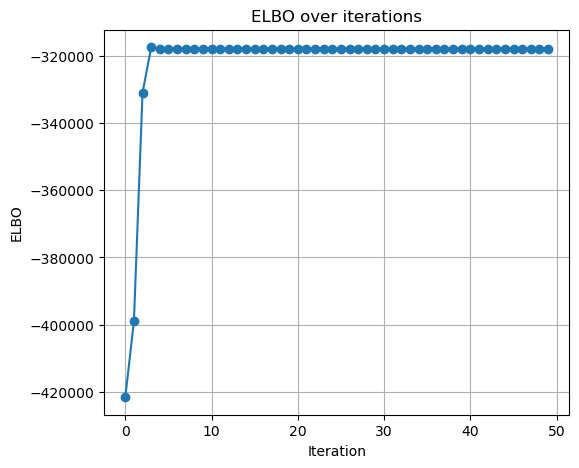

In [25]:
plt.figure(figsize=(6, 5))
plt.plot(elbo, marker='o')
plt.title("ELBO over iterations")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.grid(True)
plt.show()

## Community membership (delta) estimation

In [26]:
true_labels = np.array(df_births_deaths['com'])
pred_labels = np.argmax(delta_est, axis=1)

# Accuracy
acc = accuracy_score(true_labels, pred_labels)
print(f"VEM Accuracy: {acc:.2f}")

VEM Accuracy: 0.00


VEM Accuracy: 1.00


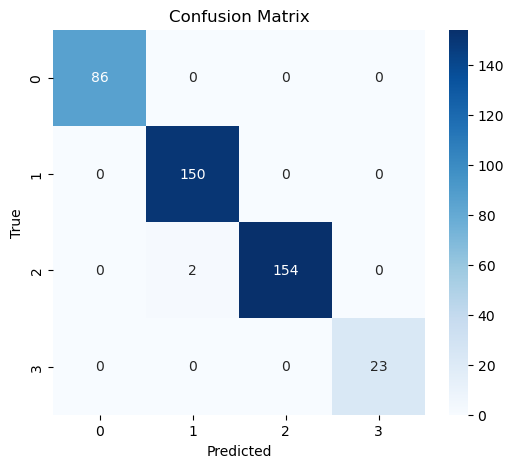

In [28]:
# Find the best label permutation to align predicted labels with the true labels
from scipy.optimize import linear_sum_assignment

# Build the confusion matrix between true and predicted labels
conf_mat = confusion_matrix(true_labels, pred_labels)

# Use the Hungarian algorithm to find the optimal one-to-one label assignment
row_ind, col_ind = linear_sum_assignment(-conf_mat) 

# Build a remapping dictionary: {old_pred_label: aligned_label}
label_map = {col: row for row, col in zip(row_ind, col_ind)}

# Relabel predicted labels according to the optimal assignment
pred_aligned = np.vectorize(label_map.get)(pred_labels)

# Compute accuracy after alignment
acc = accuracy_score(true_labels, pred_aligned)
print(f"VEM Accuracy: {acc:.2f}")

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(true_labels, pred_aligned), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

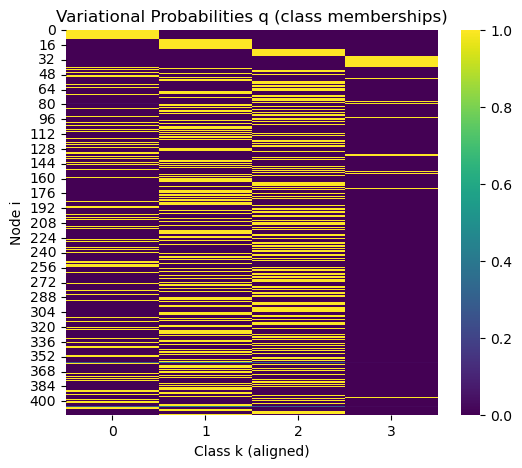

In [29]:
# Build a list defining the new column order (classes)
inverse_label_map = {v: k for k, v in label_map.items()}
new_order = [inverse_label_map[k] for k in range(delta_est.shape[1])]

# Reorder the columns of delta accordingly
delta_aligned = delta_est[:, new_order]

# Posterior probabilities heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(delta_aligned, cmap="viridis")
plt.title("Variational Probabilities q (class memberships)")
plt.xlabel("Class k (aligned)")
plt.ylabel("Node i")
plt.show()

### Parameter estimation $\theta $ = ( $\lambda$, $\mu$, $\pi$, $\beta$)

In [30]:
lambda_aligned = lambda_est[new_order]
err = lambda_aligned - lamb

print("True 𝜆:", np.round(lamb, 6))
print("Estimated 𝜆:", np.round(lambda_aligned, 6))
print("Abs error:", np.round(np.abs(err), 6))

True 𝜆: [0.05 0.04 0.03 0.02]
Estimated 𝜆: [0.037924 0.042361 0.035774 0.025528]
Abs error: [0.012076 0.002361 0.005774 0.005528]


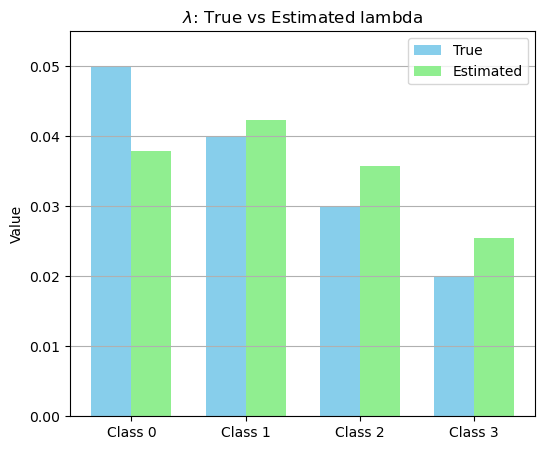

In [38]:
title="$\lambda$: True vs Estimated lambda"

x = np.arange(len(lamb))

labels=[f"Class {k}" for k in range(best_k_eff)]

width = 0.35
plt.figure(figsize=(6, 5))
plt.bar(x - width/2, lamb, width, label='True', color='skyblue')
plt.bar(x + width/2, lambda_aligned, width, label='Estimated', color='lightgreen')
plt.xticks(x, labels)
plt.ylabel("Value")
plt.title(title)
plt.legend()
plt.grid(axis='y')
plt.ylim(0, max(lamb.max(), lambda_aligned.max()) * 1.1)
plt.show()

In [39]:
mu_aligned = mu_est[new_order]
err = mu_aligned - mu

print("True 𝜇:", np.round(mu, 6))
print("Estimated 𝜇:", np.round(mu_aligned, 6))
print("Abs error:", np.round(np.abs(err), 6))

True 𝜇: [0.025 0.02  0.01  0.05 ]
Estimated 𝜇: [0.018084 0.020826 0.012924 0.044098]
Abs error: [0.006916 0.000826 0.002924 0.005902]


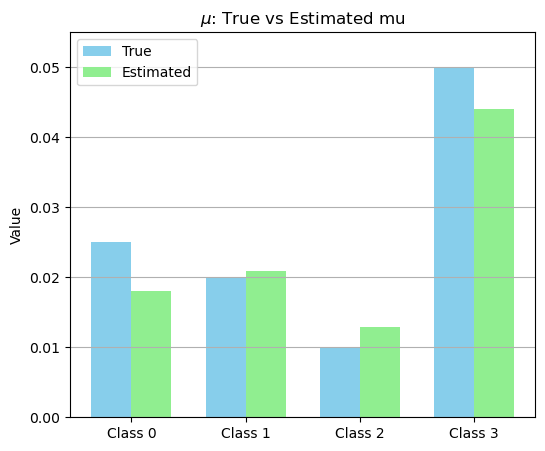

In [40]:
title="$\mu$: True vs Estimated mu"
x = np.arange(len(mu))

labels=[f"Class {k}" for k in range(best_k_eff)]

width = 0.35
plt.figure(figsize=(6, 5))
plt.bar(x - width/2, mu, width, label='True', color='skyblue')
plt.bar(x + width/2, mu_aligned, width, label='Estimated', color='lightgreen')
plt.xticks(x, labels)
plt.ylabel("Value")
plt.title(title)
plt.legend()
plt.grid(axis='y')
plt.ylim(0, max(mu.max(), mu_aligned.max()) * 1.1)
plt.show()

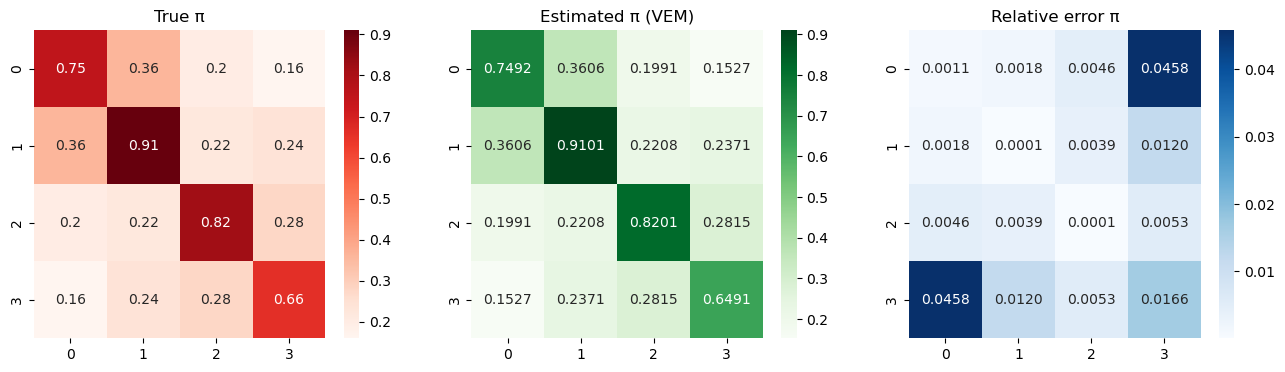

In [42]:
K = pi_est.shape[0]
label_map_inv = {v: k for k, v in label_map.items()}

# Build the permutation vector:
P = np.array([label_map_inv[i] for i in range(K)])

# Reorder the estimated pi matrix to match the aligned class ordering
pi_aligned = pi_est[P][:, P]

# Compare true vs estimated pi
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
sns.heatmap(pi_true, annot=True, cmap="Reds", ax=axs[0])
axs[0].set_title("True π")
sns.heatmap(pi_aligned, annot=True, cmap="Greens", ax=axs[1], fmt=".4f")
axs[1].set_title("Estimated π (VEM)")
sns.heatmap(abs(pi_true - pi_aligned)/pi_true, annot=True, cmap="Blues", ax=axs[2], fmt=".4f")
axs[2].set_title("Relative error π")
plt.show()

In [43]:
err = pi_aligned - pi_true
print("True π:\n", pi_true)
print("Estimated π:\n", pi_aligned)
print("Abs error:\n", np.abs(err))

True π:
 [[0.75 0.36 0.2  0.16]
 [0.36 0.91 0.22 0.24]
 [0.2  0.22 0.82 0.28]
 [0.16 0.24 0.28 0.66]]
Estimated π:
 [[0.74916548 0.36064349 0.19908111 0.1526796 ]
 [0.36064349 0.91009161 0.22084743 0.23712012]
 [0.19908111 0.22084743 0.820073   0.28149455]
 [0.1526796  0.23712012 0.28149455 0.64905347]]
Abs error:
 [[8.34521446e-04 6.43490178e-04 9.18886652e-04 7.32040362e-03]
 [6.43490178e-04 9.16127675e-05 8.47428479e-04 2.87987954e-03]
 [9.18886652e-04 8.47428479e-04 7.29965576e-05 1.49455136e-03]
 [7.32040362e-03 2.87987954e-03 1.49455136e-03 1.09465305e-02]]


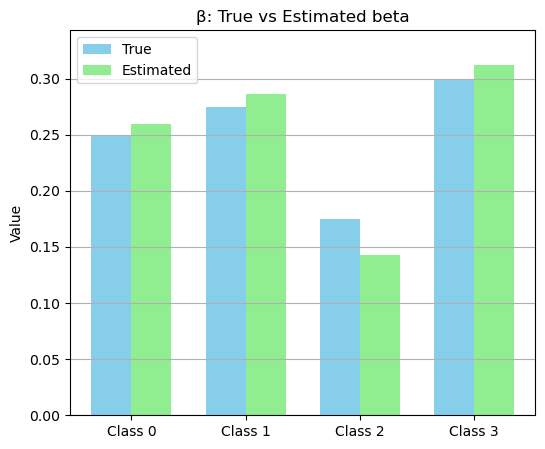

In [46]:
def plot_vector_comparison(true_vec, est_vec, labels=None, title="True vs Estimated Vector"):
    true_vec = np.array(true_vec)
    est_vec = np.array(est_vec[new_order])

    x = np.arange(len(true_vec))
    
    if labels is None:
        labels = [f"Component {i}" for i in label_map[x]]

    width = 0.35
    plt.figure(figsize=(6, 5))
    plt.bar(x - width/2, true_vec, width, label='True', color='skyblue')
    plt.bar(x + width/2, est_vec, width, label='Estimated', color='lightgreen')
    plt.xticks(x, labels)
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(axis='y')
    plt.ylim(0, max(true_vec.max(), est_vec.max()) * 1.1)
    plt.show()
    
beta_true = np.array(L_0).flatten()/np.sum(L_0)
plot_vector_comparison(beta_true, beta_est, labels=[f"Class {k}" for k in range(K)], title="β: True vs Estimated beta")

In [47]:
beta_aligned = beta_est[new_order]
err = beta_aligned - beta_true

print("True β:", np.round(beta_true, 6))
print("Estimated β:", np.round(beta_aligned, 6))
print("Abs error:", np.round(np.abs(err), 6))

True β: [0.25  0.275 0.175 0.3  ]
Estimated β: [0.259872 0.28586  0.142423 0.311845]
Abs error: [0.009872 0.01086  0.032577 0.011845]


## Accuracy over time

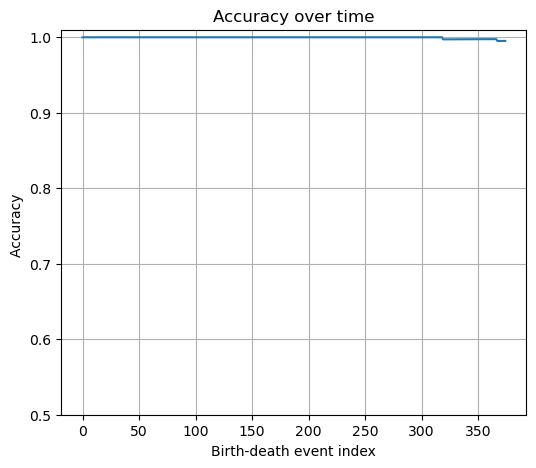

In [48]:
acc_time = []
N_t = []

# Track accuracy as the number of observed/alive nodes changes over time
for t in range(N - N_0):
    
    N_t.append(N_0+t)
    acc_time.append(accuracy_score(true_labels[0:N_0+t], pred_aligned[0:N_0+t]))
    
# Accuracy evolution over birth–death event indices
plt.figure(figsize=(6, 5))
plt.plot(acc_time, marker='')
plt.title("Accuracy over time")
plt.xlabel("Birth-death event index")
plt.ylabel("Accuracy ")
plt.ylim(0.5, 1.01)
plt.grid(True)
plt.savefig('figures/presentation_these/accuracy_pi_high.png')
plt.show()    

### Comparison with other methods

#### Initialization

VEM Accuracy: 0.25


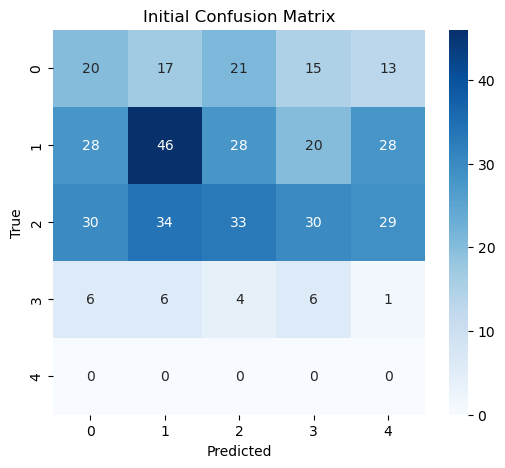

In [49]:
# Find the best label permutation to align initialization labels with the true labels
pred_labels_init = np.argmax(delta_init, axis=1)

# Build the confusion matrix between true and predicted labels
conf_mat_init = confusion_matrix(true_labels, pred_labels_init)

# Use the Hungarian algorithm to find the optimal one-to-one label assignment
row_ind, col_ind = linear_sum_assignment(-conf_mat_init) 

# Build a remapping dictionary: {old_pred_label: aligned_label}
label_map_init = {col: row for row, col in zip(row_ind, col_ind)}

# Relabel predicted labels according to the optimal assignment
pred_aligned_init = np.vectorize(label_map_init.get)(pred_labels_init)

# Compute accuracy after alignment
acc = accuracy_score(true_labels, pred_aligned_init)
print(f"VEM Accuracy: {acc:.2f}")

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(true_labels, pred_aligned_init), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Initial Confusion Matrix")
plt.show()

#### Dynamic SBM 

In [50]:
from BDSBM.Dynamic_SBM_VEM import DynamicSBM_VEM

In [51]:
# Implementation of the Dynamic SBM for the same data using the same initialization

model_dsbm = DynamicSBM_VEM(interaction_counts,
        alive_matrix,
        delta_init,
        max_iters=50,
        tol=1e-10,
    )

sol = model_dsbm.fit()

pi_est_dsbm, beta_est_dsbm, delta_est_dsbm, elbo_dsbm, icl_soft_dsbm = sol

VEM Accuracy: 0.93


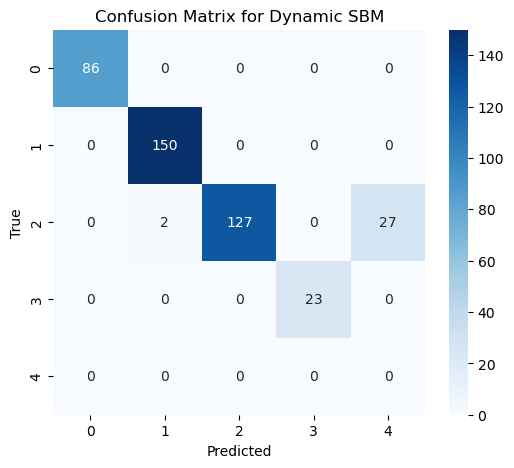

In [52]:
pred_labels_dsbm = np.argmax(delta_est_dsbm, axis=1)

# Build the confusion matrix between true and predicted labels
conf_mat = confusion_matrix(true_labels, pred_labels_dsbm)

# Use the Hungarian algorithm to find the optimal one-to-one label assignment
row_ind, col_ind = linear_sum_assignment(-conf_mat) 

# Build a remapping dictionary: {old_pred_label: aligned_label}
label_map_dsbm = {col: row for row, col in zip(row_ind, col_ind)}

# Relabel predicted labels according to the optimal assignment
pred_aligned_dsbm = np.vectorize(label_map_dsbm.get)(pred_labels_dsbm)

# Compute accuracy after alignment
acc = accuracy_score(true_labels, pred_aligned_dsbm)
print(f"VEM Accuracy: {acc:.2f}")

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(true_labels, pred_aligned_dsbm), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Dynamic SBM")
plt.show()

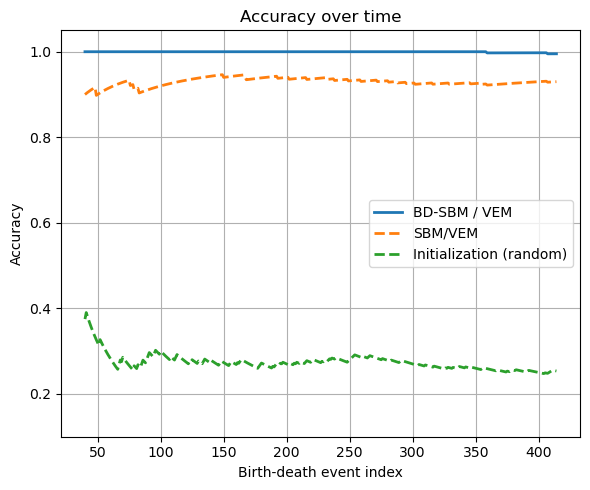

In [53]:
#acc_time = []
acc_time_init = []
acc_time_dsbm = []
N_t = []

for t in range(N - N_0):
    
    N_t.append(N_0+t)
    #acc_time.append(accuracy_score(true_labels[0:N_0+t], pred_aligned[0:N_0+t]))
    acc_time_init.append(accuracy_score(true_labels[0:N_0+t], pred_aligned_init[0:N_0+t]))
    acc_time_dsbm.append(accuracy_score(true_labels[0:N_0+t], pred_aligned_dsbm[0:N_0+t]))

# Accuracy evolution over birth–death event indices
plt.figure(figsize=(6, 5))
plt.plot(N_t, acc_time, label="BD-SBM / VEM", linewidth=2)
plt.plot(N_t, acc_time_dsbm, label="SBM/VEM", linewidth=2, linestyle="--")
plt.plot(N_t, acc_time_init, label="Initialization ("+ str(method)+")", linewidth=2, linestyle="--")
plt.title("Accuracy over time")
plt.xlabel("Birth-death event index")
plt.ylabel("Accuracy")
plt.ylim(0.1, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('figures/presentation_these/comp_accuracy_pi_high.png')
plt.show()    